# Pandas Merge and Join Method

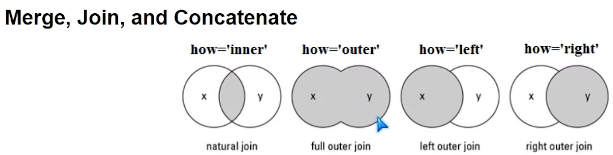

In [150]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [166]:
# df = pd.read_csv('https://raw.githubusercontent.com/AlexTheAnalyst/PandasYouTubeSeries/refs/heads/main/LOTR.csv')
# df.to_csv('resources/LOTR.csv')
df1 = pd.read_csv('resources/LOTR.csv')
df1.set_index(df1.columns[0],inplace=True)

In [167]:
df1

,FellowshipID,FirstName,Skills
Unnamed: 0,,,
0,1001,Frodo,Hiding
1,1002,Samwise,Gardening
2,1003,Gandalf,Spells
3,1004,Pippin,Fireworks


In [168]:
df2 = pd.read_csv('resources/LOTR2.csv')
df2.set_index(df2.columns[0],inplace=True)
df2

,FellowshipID,FirstName,Age
Unnamed: 0,,,
0,1001,Frodo,50
1,1002,Samwise,39
2,1006,Legolas,2931
3,1007,Elrond,6520
4,1008,Barromir,51


In [169]:
#Merge
df1.merge(df2)     #by default: inner join

,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50
1,1002,Samwise,Gardening,39


In [170]:
df1.merge(df2,how='inner')

,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50
1,1002,Samwise,Gardening,39


* Merge:
    * By Default does inner merge
    * in above case doing inner merge on 'FellowshipID' and 'FirtName'

In [171]:
#merging on FellowshipID and First Name
df1.merge(df2,how='inner',on=['FellowshipID','FirstName'])

,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50
1,1002,Samwise,Gardening,39


In [172]:
#merging on only FellowshipID 
df1.merge(df2,how='inner',on='FellowshipID')

,FellowshipID,FirstName_x,Skills,FirstName_y,Age
0,1001,Frodo,Hiding,Frodo,50
1,1002,Samwise,Gardening,Samwise,39


#### Outer Merge

In [175]:
df1.merge(df2,how='outer',on='FellowshipID')

,FellowshipID,FirstName_x,Skills,FirstName_y,Age
0,1001,Frodo,Hiding,Frodo,50.0
1,1002,Samwise,Gardening,Samwise,39.0
2,1003,Gandalf,Spells,NaN,NaN
3,1004,Pippin,Fireworks,NaN,NaN
4,1006,NaN,NaN,Legolas,2931.0
5,1007,NaN,NaN,Elrond,6520.0
6,1008,NaN,NaN,Barromir,51.0


gives
* solution for all 'FellowshipID'
* Nan(Not a number where join no merge value possible)

In [179]:
df1.merge(df2,how='left')

,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50.0
1,1002,Samwise,Gardening,39.0
2,1003,Gandalf,Spells,NaN
3,1004,Pippin,Fireworks,NaN


left i.e df1 will come full and NaN where df2 value doesn't match

In [180]:
df1.merge(df2,how='right')

,FellowshipID,FirstName,Skills,Age
0,1001,Frodo,Hiding,50
1,1002,Samwise,Gardening,39
2,1006,Legolas,NaN,2931
3,1007,Elrond,NaN,6520
4,1008,Barromir,NaN,51


In [181]:
df1.merge(df2,how='cross')

,FellowshipID_x,FirstName_x,Skills,FellowshipID_y,FirstName_y,Age
0,1001,Frodo,Hiding,1001,Frodo,50
1,1001,Frodo,Hiding,1002,Samwise,39
2,1001,Frodo,Hiding,1006,Legolas,2931
3,1001,Frodo,Hiding,1007,Elrond,6520
4,1001,Frodo,Hiding,1008,Barromir,51
5,1002,Samwise,Gardening,1001,Frodo,50
6,1002,Samwise,Gardening,1002,Samwise,39
7,1002,Samwise,Gardening,1006,Legolas,2931
8,1002,Samwise,Gardening,1007,Elrond,6520
9,1002,Samwise,Gardening,1008,Barromir,51


# Join
* must specify Left and right suffix
* Join apply on the index
* so set index to a column to make it act as merge

In [188]:
df1.join(df2,on='FellowshipID',how='outer',lsuffix='_left',rsuffix='_right')

,FellowshipID,FellowshipID_left,FirstName_left,Skills,FellowshipID_right,FirstName_right,Age
NaN,0,NaN,NaN,NaN,1001.0,Frodo,50.0
NaN,1,NaN,NaN,NaN,1002.0,Samwise,39.0
NaN,2,NaN,NaN,NaN,1006.0,Legolas,2931.0
NaN,3,NaN,NaN,NaN,1007.0,Elrond,6520.0
NaN,4,NaN,NaN,NaN,1008.0,Barromir,51.0
0.0,1001,1001.0,Frodo,Hiding,NaN,NaN,NaN
1.0,1002,1002.0,Samwise,Gardening,NaN,NaN,NaN
2.0,1003,1003.0,Gandalf,Spells,NaN,NaN,NaN
3.0,1004,1004.0,Pippin,Fireworks,NaN,NaN,NaN


In [189]:
df4 = df1.set_index('FellowshipID').join(df2.set_index('FellowshipID'),lsuffix='_Left',rsuffix='_Right')
df4

,FirstName_Left,Skills,FirstName_Right,Age
FellowshipID,,,,
1001,Frodo,Hiding,Frodo,50.0
1002,Samwise,Gardening,Samwise,39.0
1003,Gandalf,Spells,NaN,NaN
1004,Pippin,Fireworks,NaN,NaN


In [190]:
df4 = df1.set_index('FellowshipID').join(df2.set_index('FellowshipID'),lsuffix='_Left',rsuffix='_Right',how='outer')
df4

,FirstName_Left,Skills,FirstName_Right,Age
FellowshipID,,,,
1001,Frodo,Hiding,Frodo,50.0
1002,Samwise,Gardening,Samwise,39.0
1003,Gandalf,Spells,NaN,NaN
1004,Pippin,Fireworks,NaN,NaN
1006,NaN,NaN,Legolas,2931.0
1007,NaN,NaN,Elrond,6520.0
1008,NaN,NaN,Barromir,51.0


# Concat

In [191]:
pd.concat([df1,df2])

,FellowshipID,FirstName,Skills,Age
Unnamed: 0,,,,
0,1001,Frodo,Hiding,NaN
1,1002,Samwise,Gardening,NaN
2,1003,Gandalf,Spells,NaN
3,1004,Pippin,Fireworks,NaN
0,1001,Frodo,NaN,50.0
1,1002,Samwise,NaN,39.0
2,1006,Legolas,NaN,2931.0
3,1007,Elrond,NaN,6520.0
4,1008,Barromir,NaN,51.0


In [193]:
pd.concat([df1,df2],join='inner')
#only common columns are joined

,FellowshipID,FirstName
Unnamed: 0,,
0,1001,Frodo
1,1002,Samwise
2,1003,Gandalf
3,1004,Pippin
0,1001,Frodo
1,1002,Samwise
2,1006,Legolas
3,1007,Elrond
4,1008,Barromir


In [195]:
pd.concat([df1,df2],join='outer')
#outer join is default in concat

,FellowshipID,FirstName,Skills,Age
Unnamed: 0,,,,
0,1001,Frodo,Hiding,NaN
1,1002,Samwise,Gardening,NaN
2,1003,Gandalf,Spells,NaN
3,1004,Pippin,Fireworks,NaN
0,1001,Frodo,NaN,50.0
1,1002,Samwise,NaN,39.0
2,1006,Legolas,NaN,2931.0
3,1007,Elrond,NaN,6520.0
4,1008,Barromir,NaN,51.0
